# Fashion-MNIST exploratory data analysis

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import torchvision

from src.interfaces import CLASS_NAMES, IMAGE_SHAPE, NUM_CLASSES

FIGURES = "../results/eda"

train = torchvision.datasets.FashionMNIST(root="../data", train=True, download=False)
test = torchvision.datasets.FashionMNIST(root="../data", train=False, download=False)

train_images, train_labels = train.data.numpy(), train.targets.numpy()
test_images, test_labels = test.data.numpy(), test.targets.numpy()

print(f"train: {len(train_images)} images, test: {len(test_images)} images")


## Input format

Grayscale, `28x28`, `uint8`, `[0, 255]`.

In [2]:
print(f"shape: {train_images.shape[1:]}, channels: {IMAGE_SHAPE[0]}")
print(f"dtype: {train_images.dtype}")
print(f"value range: [{train_images.min()}, {train_images.max()}]")
print(f"classes: {NUM_CLASSES}")


shape: (28, 28), channels: 1
dtype: uint8
value range: [0, 255]
classes: 10


## Class distribution

Both splits are balanced by construction: 6,000 images per class in training, 1,000 per
class in test.

In [3]:
def class_counts(labels):
    values, counts = np.unique(labels, return_counts=True)
    return {CLASS_NAMES[v]: int(c) for v, c in zip(values, counts)}

train_counts = class_counts(train_labels)
test_counts = class_counts(test_labels)

for name in CLASS_NAMES:
    print(f"{name:<14} train {train_counts[name]:>6}   test {test_counts[name]:>6}")


T-shirt/top    train   6000   test   1000
Trouser        train   6000   test   1000
Pullover       train   6000   test   1000
Dress          train   6000   test   1000
Coat           train   6000   test   1000
Sandal         train   6000   test   1000
Shirt          train   6000   test   1000
Sneaker        train   6000   test   1000
Bag            train   6000   test   1000
Ankle boot     train   6000   test   1000


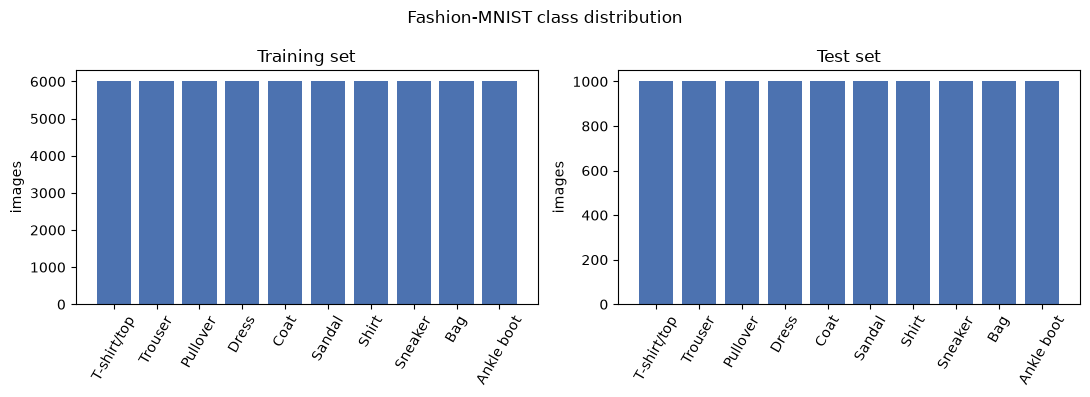

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, counts, title in zip(axes, (train_counts, test_counts), ("Training set", "Test set")):
    ax.bar(CLASS_NAMES, counts.values(), color="#4C72B0")
    ax.set_title(title)
    ax.set_ylabel("images")
    ax.tick_params(axis="x", rotation=60)
fig.suptitle("Fashion-MNIST class distribution")
fig.tight_layout()
fig.savefig(f"{FIGURES}/class_distribution.png", dpi=150)
plt.show()


## Class imbalance

Max-to-min per-class count ratio.

In [5]:
def imbalance_ratio(counts):
    values = list(counts.values())
    return max(values) / min(values)

print(f"train max-to-min ratio: {imbalance_ratio(train_counts):.3f}")
print(f"test max-to-min ratio: {imbalance_ratio(test_counts):.3f}")


train max-to-min ratio: 1.000
test max-to-min ratio: 1.000


## Representative sample grid

One example per class, training set.

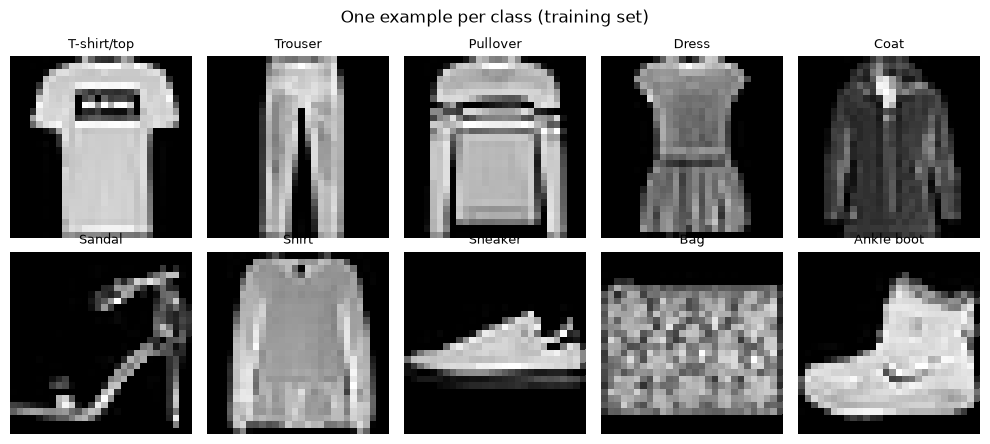

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for label, ax in enumerate(axes.flat):
    idx = np.flatnonzero(train_labels == label)[0]
    ax.imshow(train_images[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
fig.suptitle("One example per class (training set)")
fig.tight_layout()
fig.savefig(f"{FIGURES}/sample_grid.png", dpi=150)
plt.show()


## Pixel intensity statistics

Raw pixel intensity distribution, training set, overall and per class.

In [7]:
overall_mean, overall_std = train_images.mean(), train_images.std()
print(f"overall pixel mean: {overall_mean:.2f}, std: {overall_std:.2f}")

per_class_stats = {
    CLASS_NAMES[label]: (train_images[train_labels == label].mean(), train_images[train_labels == label].std())
    for label in range(NUM_CLASSES)
}
for name, (mean, std) in per_class_stats.items():
    print(f"{name:<14} mean {mean:6.2f}   std {std:6.2f}")


overall pixel mean: 72.94, std: 90.02
T-shirt/top    mean  83.03   std  89.44
Trouser        mean  56.84   std  87.60
Pullover       mean  96.06   std  91.46
Dress          mean  66.02   std  90.33
Coat           mean  98.26   std  95.96
Sandal         mean  34.87   std  67.09
Shirt          mean  84.61   std  86.52
Sneaker        mean  42.76   std  75.17
Bag            mean  90.16   std  93.14
Ankle boot     mean  76.81   std  94.49


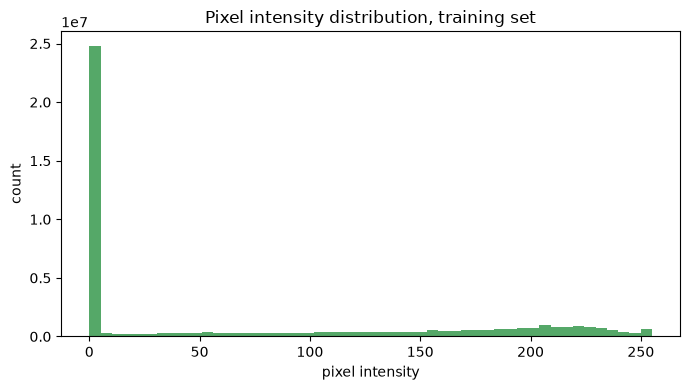

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_images.reshape(-1), bins=50, color="#55A868")
ax.set_xlabel("pixel intensity")
ax.set_ylabel("count")
ax.set_title("Pixel intensity distribution, training set")
fig.tight_layout()
fig.savefig(f"{FIGURES}/pixel_intensity.png", dpi=150)
plt.show()


## Visually confusable class pairs

Cosine similarity between per-class mean images; higher similarity means harder to
separate on raw pixels.

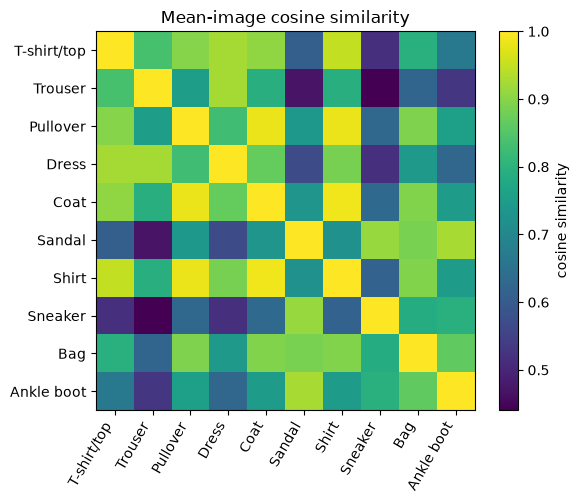

In [9]:
class_means = np.stack([train_images[train_labels == label].mean(axis=0) for label in range(NUM_CLASSES)])
flat = class_means.reshape(NUM_CLASSES, -1)
norm = flat / np.linalg.norm(flat, axis=1, keepdims=True)
similarity = norm @ norm.T

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(similarity, cmap="viridis", vmin=similarity[~np.eye(NUM_CLASSES, dtype=bool)].min(), vmax=1.0)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=60, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_title("Mean-image cosine similarity")
fig.colorbar(im, ax=ax, label="cosine similarity")
fig.tight_layout()
fig.savefig(f"{FIGURES}/class_similarity.png", dpi=150)
plt.show()


In [10]:
pairs = []
for i in range(NUM_CLASSES):
    for j in range(i + 1, NUM_CLASSES):
        pairs.append((similarity[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
pairs.sort(reverse=True)

print("most visually confusable class pairs (by mean-image cosine similarity):")
for score, a, b in pairs[:5]:
    print(f"  {a:<14} vs {b:<14} {score:.4f}")


most visually confusable class pairs (by mean-image cosine similarity):
  Coat           vs Shirt          0.9874
  Pullover       vs Coat           0.9841
  Pullover       vs Shirt          0.9832
  T-shirt/top    vs Shirt          0.9489
  Sandal         vs Ankle boot     0.9269


Coat, Shirt, Pullover, and T-shirt/top form the most similar cluster (cosine similarity
up to 0.99): upper-body garments with comparable silhouettes at 28x28 resolution. Sandal
and Ankle boot are the next closest pair, differing mainly by a thin strap versus a solid
upper. Trouser and Bag have the most distinctive outlines and should be the easiest to
classify.